In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_excel("D:/code/venv/Online Retail.xlsx")


In [10]:
df.shape#To explore no of rows and columns



(541909, 8)

In [11]:
df.head()#To display only first 5rows of dataframe

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.tail()#To display only last 5 rows in dataFrame

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [13]:
df.columns#To show only the column names in data frame

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [14]:
df.info() #InvoiceDate is already in Datetime datatype

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [15]:
df.dropna(subset='CustomerID',inplace=True) #To remove null values using customer id column

In [16]:
df['CustomerID'].isnull().value_counts() #To check for null values

CustomerID
False    406829
Name: count, dtype: int64

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.loc[df['Quantity']<0] #To check for negative quantity
df.drop(df[df['Quantity']<0].index,inplace=True) #To remove negative quantity rows

In [20]:
df.loc[df['UnitPrice']==0.0]  #To check for invalid unit price
df.drop(df[df['UnitPrice']==0].index,inplace=True)

In [21]:
df['TotalPrice']=df['Quantity'] * df['UnitPrice'] # tO CREATE new column 'total price'

In [22]:
df['Year']=df['InvoiceDate'].dt.year  #To create a new column as year using invoice date Column

In [23]:
df['month']=df['InvoiceDate'].dt.month #To create a new column as month using invoice date Column

In [24]:
df['day']=df['InvoiceDate'].dt.day #To create a new column as Day of the month using invoice date Column

In [25]:
df['hour']=df['InvoiceDate'].dt.hour #To create a new column as hour using invoice date Column

In [26]:

conditions=[
    (df['TotalPrice']<=100),
    (df['TotalPrice']<=500),
    (df['TotalPrice']<=df['TotalPrice'].max()),
]
Values=['Low','Medium','High']
df['Customer Segment']=np.select(conditions,Values,default='N')


In [27]:
df['Order Size']=np.where(df['Quantity']>500 ,'Large','Small' )


In [28]:
df['DayType']=np.where(((df['InvoiceDate'].dt.day_of_week >=0) & (df['InvoiceDate'].dt.day_of_week <=4) ) , 'Weekday' ,'weekend')

In [29]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,month,day,hour
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661


In [30]:
df['Customer Segment'].value_counts()

Customer Segment
Low       381042
Medium     10737
High         913
Name: count, dtype: int64

In [31]:
df['StockCode'].unique()

array(['85123A', 71053, '84406B', ..., '90214Z', 90089, 23843],
      shape=(3665,), dtype=object)

In [32]:
df.groupby('Country').agg(list)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,month,day,hour,Customer Segment,Order Size,DayType
Country,,,,,,,,,,,,,,,
Australia,"[536389, 536389, 536389, 536389, 536389, 53638...","[22941, 21622, 21791, 35004C, 35004G, 85014B, ...","[CHRISTMAS LIGHTS 10 REINDEER, VINTAGE UNION J...","[6, 8, 12, 6, 4, 6, 3, 2, 4, 4, 2, 2, 24, 24, ...","[2010-12-01 10:03:00, 2010-12-01 10:03:00, 201...","[8.5, 4.95, 1.25, 5.45, 6.35, 5.95, 5.95, 8.5,...","[12431.0, 12431.0, 12431.0, 12431.0, 12431.0, ...","[51.0, 39.6, 15.0, 32.7, 25.4, 35.7, 17.85, 17...","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8, ...","[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
Austria,"[539330, 539330, 539330, 539330, 539330, 53933...","[37449, 37446, 22962, 21428, 22113, 22313, 223...","[CERAMIC CAKE STAND + HANGING CAKES, MINI CAKE...","[8, 8, 12, 4, 4, 6, 6, 3, 10, 20, 12, 30, 20, ...","[2010-12-17 09:38:00, 2010-12-17 09:38:00, 201...","[8.5, 1.45, 0.85, 4.25, 3.75, 2.95, 2.95, 40.0...","[12370.0, 12370.0, 12370.0, 12370.0, 12370.0, ...","[68.0, 11.6, 10.2, 17.0, 15.0, 17.700000000000...","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 12, 2, 2, 2, 2, 2...","[17, 17, 17, 17, 17, 17, 17, 17, 1, 1, 1, 1, 1...","[9, 9, 9, 9, 9, 9, 9, 9, 13, 13, 13, 13, 13, 1...","[Low, Low, Low, Low, Low, Low, Low, Medium, Lo...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
Bahrain,"[552449, 552449, 552449, 552449, 552449, 55244...","[22693, 23076, 23077, 22890, 22649, 22423, 850...","[GROW A FLYTRAP OR SUNFLOWER IN TIN, ICE CREAM...","[24, 96, 60, 2, 8, 2, 12, 6, 6, 6, 6, 6, 6, 2,...","[2011-05-09 13:49:00, 2011-05-09 13:49:00, 201...","[1.25, 1.25, 1.25, 9.95, 4.95, 12.75, 1.65, 2....","[12355.0, 12355.0, 12355.0, 12355.0, 12355.0, ...","[30.0, 120.0, 75.0, 19.9, 39.6, 25.5, 19.79999...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 19, 19...","[13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1...","[Low, Medium, Low, Low, Low, Low, Low, Low, Lo...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
Belgium,"[537026, 537026, 537026, 537026, 537026, 53702...","[84375, 21217, 21212, 21977, 22417, 21975, 219...","[SET OF 20 KIDS COOKIE CUTTERS, RED RETROSPOT ...","[12, 2, 120, 120, 120, 48, 48, 12, 10, 10, 24,...","[2010-12-03 16:35:00, 2010-12-03 16:35:00, 201...","[2.1, 9.95, 0.42, 0.42, 0.42, 0.55, 0.55, 1.65...","[12395.0, 12395.0, 12395.0, 12395.0, 12395.0, ...","[25.200000000000003, 19.9, 50.4, 50.4, 50.4, 2...","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 17, 17, 1...","[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
Brazil,"[550201, 550201, 550201, 550201, 550201, 55020...","[22423, 22699, 22697, 22698, 22366, 21430, 226...","[REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACU...","[16, 24, 24, 24, 10, 24, 24, 10, 12, 10, 3, 3,...","[2011-04-15 10:25:00, 2011-04-15 10:25:00, 201...","[10.95, 2.55, 2.55, 2.55, 6.75, 3.39, 1.95, 1....","[12769.0, 12769.0, 12769.0, 12769.0, 12769.0, ...","[175.2, 61.199999999999996, 61.199999999999996...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...","[15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 1...","[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1...","[Medium, Low, Low, Low, Low, Low, Low, Low, Lo...

In [33]:
df.groupby('month').agg(list)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,day,hour,Customer Segment,Order Size,DayType
month,,,,,,,,,,,,,,,
1,"[539993, 539993, 539993, 539993, 539993, 53999...","[22386, 21499, 21498, 22379, 20718, 85099B, 20...","[JUMBO BAG PINK POLKADOT, BLUE POLKADOT WRAP, ...","[10, 25, 25, 5, 10, 10, 6, 12, 6, 8, 6, 6, 6, ...","[2011-01-04 10:00:00, 2011-01-04 10:00:00, 201...","[1.95, 0.42, 0.42, 2.1, 1.25, 1.95, 3.25, 1.45...","[13313.0, 13313.0, 13313.0, 13313.0, 13313.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[19.5, 10.5, 10.5, 10.5, 12.5, 19.5, 19.5, 17....","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...","[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
2,"[542776, 542776, 542776, 542776, 542776, 54277...","[21671, 21668, 21670, 17013D, 17096, 22469, 22...","[RED SPOT CERAMIC DRAWER KNOB, RED STRIPE CERA...","[48, 12, 12, 96, 48, 12, 12, 4, 1, 4, 12, 36, ...","[2011-02-01 08:23:00, 2011-02-01 08:23:00, 201...","[1.25, 1.25, 1.25, 0.42, 0.21, 1.65, 1.65, 4.9...","[15240.0, 15240.0, 15240.0, 15240.0, 15240.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[60.0, 15.0, 15.0, 40.32, 10.08, 19.7999999999...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
3,"[545220, 545220, 545220, 545220, 545220, 54522...","[21955, 48194, 22556, 22139, 84029G, 21485, 17...","[DOORMAT UNION JACK GUNS AND ROSES, DOORMAT HE...","[2, 2, 12, 3, 4, 3, 6, 6, 12, 2, 2, 3, 8, 6, 2...","[2011-03-01 08:30:00, 2011-03-01 08:30:00, 201...","[7.95, 7.95, 1.65, 4.95, 3.75, 4.95, 1.25, 2.5...","[14620.0, 14620.0, 14620.0, 14620.0, 14620.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[15.9, 15.9, 19.799999999999997, 14.8500000000...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
4,"[548550, 548550, 548550, 548550, 548550, 54855...","[22662, 22296, 21790, 22622, 22393, 85061W, 22...","[LUNCH BAG DOLLY GIRL DESIGN, HEART IVORY TREL...","[10, 12, 12, 2, 6, 24, 6, 3, 6, 2, 16, 10, 4, ...","[2011-04-01 08:22:00, 2011-04-01 08:22:00, 201...","[1.65, 1.65, 0.85, 9.95, 2.55, 0.85, 4.95, 12....","[18161.0, 18161.0, 18161.0, 18161.0, 18161.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[16.5, 19.799999999999997, 10.2, 19.9, 15.2999...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
5,"[551515, 551515, 551515, 551515, 551515, 55151...","[21731, 20749, 22729, 22998, 22665, 22371, 207...","[RED TOADSTOOL LED NIGHT LIGHT, ASSORTED COLOU...","[12, 12, 8, 24, 24, 12, 12, 1, 1, 1, 1, 1, 1, ...","[2011-05-01 10:51:00, 2011-05-01 10:51:00, 201...","[1.65, 6.35, 3.75, 0.42, 2.55, 3.95, 6.35, 1.2...","[15606.0, 15606.0, 15606.0, 15606.0, 15606.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[19.799999999999997, 76.19999999999999, 30.0, ...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small,

In [ ]:
df.groupby('StockCode').agg(list) #Perform groupBY in product

,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,month,day,hour,Customer Segment,Order Size,DayType
StockCode,,,,,,,,,,,,,,,
10002,"[536370, 536382, 536863, 537047, 537227, 53777...","[INFLATABLE POLITICAL GLOBE , INFLATABLE POLIT...","[48, 12, 1, 1, 24, 12, 8, 10, 12, 12, 36, 12, ...","[2010-12-01 08:45:00, 2010-12-01 09:45:00, 201...","[0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.8...","[12583.0, 16098.0, 17967.0, 13069.0, 17677.0, ...","[France, United Kingdom, United Kingdom, Unite...","[40.8, 10.2, 0.85, 0.85, 20.4, 10.2, 6.8, 8.5,...","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...","[1, 1, 3, 5, 6, 8, 9, 9, 9, 9, 10, 10, 13, 14,...","[8, 9, 11, 11, 8, 12, 14, 14, 14, 18, 10, 12, ...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, weekend, Weekday, ..."
10080,"[545060, 557568, 558911, 561322, 561925, 56204...","[GROOVY CACTUS INFLATABLE, GROOVY CACTUS INFLA...","[2, 48, 12, 12, 12, 24, 12, 12, 12, 24, 12, 12...","[2011-02-27 13:47:00, 2011-06-21 10:40:00, 201...","[0.85, 0.39, 0.39, 0.39, 0.39, 0.39, 0.39, 0.3...","[15547.0, 17629.0, 14189.0, 15203.0, 16551.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[1.7, 18.72, 4.68, 4.68, 4.68, 9.36, 4.68, 4.6...","[2011, 2011, 2011, 2011, 2011, 2011, 2011, 201...","[2, 6, 7, 7, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 1...","[27, 21, 5, 26, 1, 2, 3, 22, 5, 8, 19, 27, 10,...","[13, 10, 9, 13, 12, 10, 8, 15, 15, 8, 10, 9, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[weekend, Weekday, Weekday, Weekday, Weekday, ..."
10120,"[536863, 536987, 537769, 538205, 544460, 54563...","[DOGGY RUBBER, DOGGY RUBBER, DOGGY RUBBER, DOG...","[1, 2, 12, 1, 30, 11, 8, 8, 1, 1, 2, 5, 5, 30,...","[2010-12-03 11:19:00, 2010-12-03 14:54:00, 201...","[0.21, 0.21, 0.21, 0.21, 0.21, 0.21, 0.21, 0.2...","[17967.0, 17198.0, 15021.0, 12748.0, 16931.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[0.21, 0.42, 2.52, 0.21, 6.3, 2.31, 1.68, 1.68...","[2010, 2010, 2010, 2010, 2011, 2011, 2011, 201...","[12, 12, 12, 12, 2, 3, 3, 3, 3, 5, 5, 7, 8, 8,...","[3, 3, 8, 10, 20, 4, 7, 7, 30, 15, 17, 7, 2, 2...","[11, 14, 12, 11, 14, 12, 13, 14, 12, 16, 12, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, weekend, ..."
10125,"[536464, 537351, 537689, 537850, 538558, 53889...","[MINI FUNKY DESIGN TAPES, MINI FUNKY DESIGN TA...","[2, 1, 20, 20, 20, 20, 60, 40, 20, 20, 20, 20,...","[2010-12-01 12:23:00, 2010-12-06 12:23:00, 201...","[0.85, 0.85, 0.85, 0.85, 0.42, 0.42, 0.42, 0.4...","[17968.0, 16898.0, 15750.0, 16722.0, 13069.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[1.7, 0.85, 17.0, 17.0, 8.4, 8.4, 25.2, 16.8, ...","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 1, 1, 1, 1, 1, 1,...","[1, 6, 8, 8, 13, 15, 15, 6, 6, 7, 10, 10, 11, ...","[12, 12, 10, 15, 10, 9, 11, 10, 14, 12, 10, 11...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, Small, Small, Small, Small, Small, Sma...","[Weekday, Weekday, Weekday, Weekday, Weekday, ..."
10133,"[536446, 537126, 537155, 537225, 537374, 53806...","[COLOURING PENCILS BROWN TUBE, COLOURING PENCI...","[5, 1, 3, 10, 2, 2, 10, 10, 20, 20, 20, 10, 10...","[2010-12-01 12:15:00, 2010-12-05 12:13:00, 201...","[0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.8...","[15983.0, 18118.0, 12748.0, 12748.0, 17259.0, ...","[United Kingdom, United Kingdom, United Kingdo...","[4.25, 0.85, 2.55, 8.5, 1.7, 1.7, 8.5, 8.5, 8....","[2010, 2010, 2010, 2010, 2010, 2010, 2010, 201...","[12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...","[1, 5, 5, 5, 6, 9, 9, 16, 16, 16, 17, 19, 23, ...","[12, 12, 13, 16, 12, 13, 14, 13, 13, 14, 11, 1...","[Low, Low, Low, Low, Low, Low, Low, Low, Low, ...","[Small, 

In [ ]:
df.groupby(by=['Year','month'])['InvoiceNo'].count() # To find sales for every month and year

Year  month
2010  12       25670
2011  1        20988
      2        19706
      3        26870
      4        22433
      5        28073
      6        26926
      7        26580
      8        26790
      9        39669
      10       48793
      11       63168
      12       17026
Name: InvoiceNo, dtype: int64

In [35]:
df.groupby('StockCode')['Quantity'].sum()

StockCode
10002     823
10080     291
10120     192
10125    1225
10133    2373
         ... 
C2        134
DOT        16
M        6933
PADS        3
POST     3120
Name: Quantity, Length: 3665, dtype: int64

In [36]:
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False) #Sort to find top Customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
             ...    
16878.0        13.30
17956.0        12.75
16454.0         6.90
14792.0         6.20
16738.0         3.75
Name: TotalPrice, Length: 4338, dtype: float64

In [37]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False) #Sort to find top Countries

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [38]:
df['Quantity'].sum()

np.int64(5152002)

In [39]:
df['UnitPrice'].sum()

np.float64(1227521.384)

In [40]:
df['TotalPrice'].sum()

np.float64(8887208.894000001)

In [41]:
df['Description'].mode()

0    WHITE HANGING HEART T-LIGHT HOLDER
Name: Description, dtype: object

In [42]:
df['TotalPrice'].mean()

np.float64(22.631499735161402)

In [43]:
df['Quantity'].median()

np.float64(6.0)

In [44]:
df['UnitPrice'].mode()

0    1.25
Name: UnitPrice, dtype: float64

In [45]:
df['TotalPrice'].std()

np.float64(311.09922433480364)

In [46]:
df['UnitPrice'].var()

np.float64(494.6992514825076)

In [47]:
df['Quantity'].quantile(0.80)

np.float64(12.0)

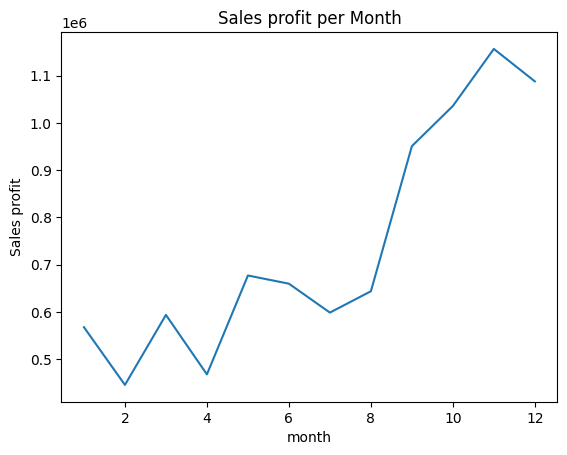

In [ ]:
df.groupby('month')['TotalPrice'].sum().plot(kind='line',ylabel='Sales profit') #line chart
plt.title('Sales profit per Month')
plt.show()

In [43]:
df.groupby('month')['TotalPrice'].sum()

,TotalPrice
month,
1,568101.310
2,446084.920
3,594081.760
4,468374.331
5,677355.150
6,660046.050
7,598962.901
8,644051.040
9,950690.202


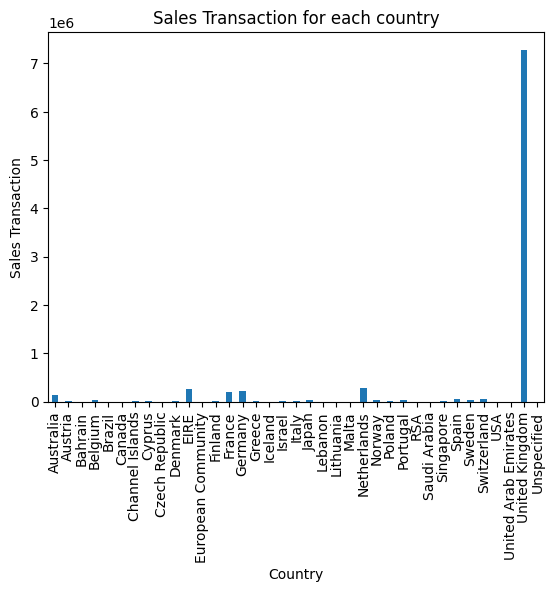

In [51]:
df.groupby('Country')['TotalPrice'].sum().plot(kind='bar')
plt.title("Sales Transaction for each country")
plt.ylabel('Sales Transaction')
plt.show()

In [45]:
df.groupby('Country')['TotalPrice'].sum()

,TotalPrice
Country,
Australia,138453.810
Austria,10198.680
Bahrain,548.400
Belgium,41196.340
Brazil,1143.600
Canada,3666.380
Channel Islands,20440.540
Cyprus,13502.850
Czech Republic,826.740


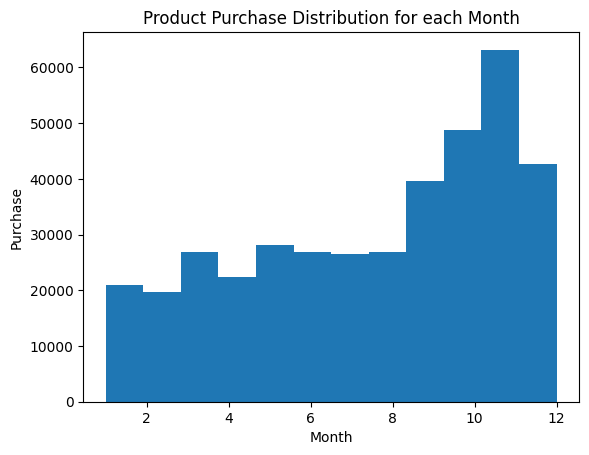

In [52]:
plt.hist(df['month'],bins=12)   #Histogram showing  Product Distribution
plt.xlabel('Month')
plt.ylabel('Purchase')
plt.title('Product Purchase Distribution for each Month')
plt.show()

In [47]:
df['month'].value_counts()

,count
month,
11,63168
10,48793
12,42696
9,39669
5,28073
6,26926
3,26870
8,26790
7,26580


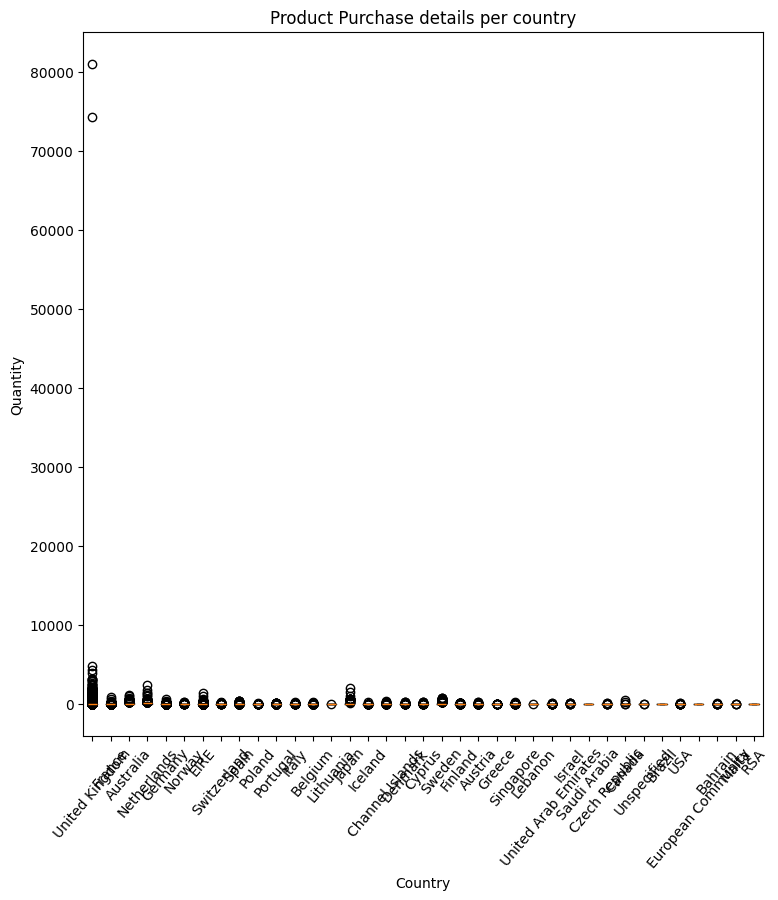

In [57]:
countryList=df['Country'].unique()
data=[df[df['Country']==country]['Quantity'] for country in countryList]
plt.figure(figsize=(8,8))
plt.boxplot(data,tick_labels=countryList)
plt.title('Product Purchase details per country')
plt.xlabel('Country')
plt.ylabel('Quantity')
plt.tight_layout()
plt.xticks(rotation=50)
plt.show()


In [49]:
df.groupby('Description')['Quantity'].count().sort_values(ascending=False)

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1713
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1389
...,...
BLUE/YELLOW CERAMIC CANDLE HOLDER,1
BLUE/NAT SHELL NECKLACE W PENDANT,1
BLUE/GREEN SHELL NECKLACE W PENDANT,1


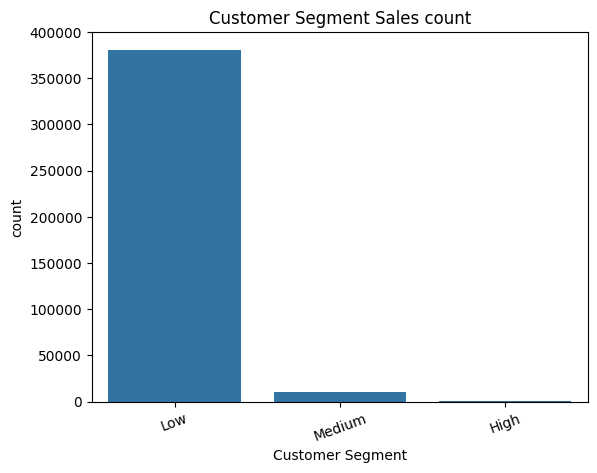

In [50]:
sns.countplot(x='Customer Segment',data=df)
plt.title('Customer Segment Sales count')
plt.xticks(rotation=20)
plt.show()

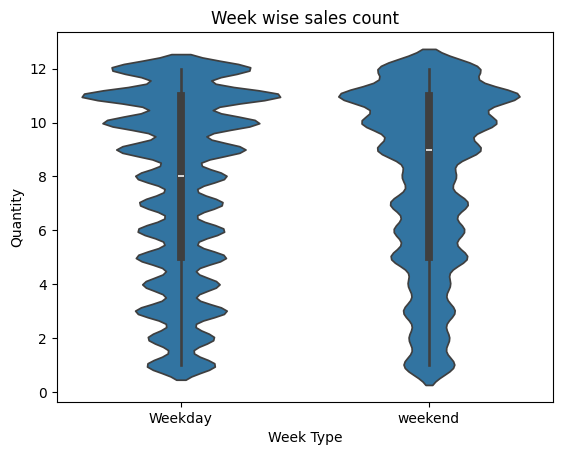

In [62]:
sns.violinplot(x='DayType',y='month',data=df)
plt.title('Week wise sales count')
plt.xlabel('Week Type')
plt.ylabel('Quantity')
plt.show()

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  object        
 1   StockCode         392692 non-null  object        
 2   Description       392692 non-null  object        
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[ns]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  float64       
 7   Country           392692 non-null  object        
 8   TotalPrice        392692 non-null  float64       
 9   Year              392692 non-null  int32         
 10  month             392692 non-null  int32         
 11  day               392692 non-null  int32         
 12  hour              392692 non-null  int32         
 13  Customer Segment  392692 non-null  object        
 14  Order Siz

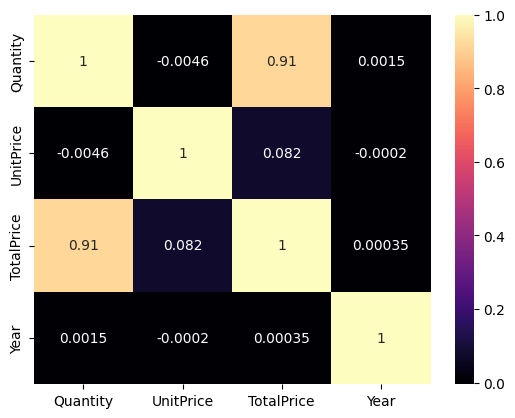

In [53]:
corr=df[['Quantity','UnitPrice','TotalPrice','Year']].corr()
sns.heatmap(corr,annot=True,cmap='magma')
plt.show()

In [54]:
sns.pairplot(df,hue='Country',palette='magma',vars=['Quantity','UnitPrice','TotalPrice','Year'])
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7c5cabefe480> (for post_execute):


KeyboardInterrupt: 

In [58]:
df['Country'].mode() #Top Country

,Country
0,United Kingdom


In [66]:
import datetime
a=df['month'].mode()
month_name = datetime.date(2000, a[0], 1).strftime('%B')
month_name


'November'

In [71]:
df.groupby('month')['TotalPrice'].sum().sort_values(ascending=False).iloc[:3] #{Peak Sales Time}

,TotalPrice
month,
11,1156205.61
12,1087613.17
10,1035642.45


In [72]:
df.groupby('Customer Segment').value_counts()

Customer Segment  InvoiceNo  StockCode  Description                         Quantity  InvoiceDate          UnitPrice  CustomerID  Country         TotalPrice  Year  month  day  hour  Order Size  DayType
High              536387     21731      RED TOADSTOOL LED NIGHT LIGHT       432       2010-12-01 09:58:00  1.25       16029.0     United Kingdom  540.00      2010  12     1    9     Small       Weekday    1
                             22466      FAIRY TALE COTTAGE NIGHTLIGHT       432       2010-12-01 09:58:00  1.45       16029.0     United Kingdom  626.40      2010  12     1    9     Small       Weekday    1
                             22779      WOODEN OWLS LIGHT GARLAND           192       2010-12-01 09:58:00  3.37       16029.0     United Kingdom  647.04      2010  12     1    9     Small       Weekday    1
                             22780      LIGHT GARLAND BUTTERFILES PINK      192       2010-12-01 09:58:00  3.37       16029.0     United Kingdom  647.04      2010  12     1    9     Small       Weekday    1
                             79321      CHILLI LIGHTS                       192       2010-12-01 09:58:00  3.82       16029.0     United Kingdom  733.44      2010  12     1    9     Small       Weekday    1
                                                                                                                                                                                                            ..
Medium            581495     15056BL    EDWARDIAN PARASOL BLACK             36        2011-12-09 10:20:00  5.95       14051.0     United Kingdom  214.20      2011  12     9    10    Small       Weekday    1
                             15056N     EDWARDIAN PARASOL NATURAL           36        2011-12-09 10:20:00  5.95       14051.0     United Kingdom  214.20      2011  12     9    10    Small       Weekday    1
                  581566     23404      HOME SWEET HOME BLACKBOARD          144       2011-12-09 11:50:00  3.26       18102.0     United Kingdom  469.44      2011  12     9    11    Small       Weekday    1
                  581572     23328      SET 6 SCHOOL MILK BOTTLES IN CRATE  48        2011-12-09 12:08:00  3.39       16705.0     United Kingdom  162.72      2011  12     9    12    Small       Weekday    1
                  581586     21217      RED RETROSPOT ROUND CAKE TINS       24        2011-12-09 12:49:00  8.95       13113.0     United Kingdom  214.80      2011  12     9    12    Small       Weekday    1
Name: count, Length: 392692, dtype: int64

In [73]:
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
...,...
16878.0,13.30
17956.0,12.75
16454.0,6.90


In [76]:
df.groupby('Description')['Description'].count().sort_values(ascending=False)

,Description
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1713
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1389
...,...
BLUE/YELLOW CERAMIC CANDLE HOLDER,1
BLUE/NAT SHELL NECKLACE W PENDANT,1
BLUE/GREEN SHELL NECKLACE W PENDANT,1


In [ ]:
df.to_excel('D:\code\venv\my_data.xlsx', index=False, sheet_name='Retail Dataset')


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_22166/3184102365.py:1: SyntaxWarning: invalid escape sequence '\c'
  df.to_excel('D:\code\venv\my_data.xlsx', index=False, sheet_name='Retail Dataset')
